# Chapter 3: Transformers

In the last chapter we saw how to use neural networks to model text. The LSTM was able to learn the structure of text with a larger context window size. However due to its recurrent nature, it requires to process the text sequentially in training and inference, which is not efficient. In this chapter we will see how to produce efficient models.

<img src="./img/bac.png" alt="Neuron" width="800" height="400">

The LSTM architecture maintains a hidden state and memory embeddings that are updated iteratively for each new token. This allows it to capture long-term dependencies but it is hard to parallelize the computations without taking advantage of current hardware capabilities to process multidimensional data. To improve the effectiveness of this model we will compute the memory and current state on the fly for each new token taking advantage of parallel computations.

## Attention is all you need

To compute the memory and current state for each new token, we need to be able to retrieve information from previous tokens in the sequence in an efficient way. Let's start simply by retrieving a token in a list and improve from it.

Consider the following list: [1, 4, 7, 6, 9, 2]. If the relevant token we want to retrieve is 7, we can search for its index using the list method `index`:

In [1]:
import math

token = 7

sequence = [1, 4, 7, 6, 9, 2]

print(sequence.index(token))

2


This search requires to iterate over the list until we find the token. If we have multiple lists to retrieve from, we also need to iterate over each list. This is not efficient to apply in our model. We need a way to find the relevant token index in parallel and potentially over multiple sequences.

Since our token is a number, we can compute the distance to each token and retrieve the position of the token with smaller distance. By computing this in PyTorch we can take advantage of parallel tensor computations to find the relevant token index in multiple sequences in parallel. We can use `argmax` function in PyTorch to get the index of the maximun value in a tensor. However, the distance to the relevant token is the minimum distance, so we can compute the inverse using this formula:

$$ score = \frac{1}{(token - token_{seq})^2 + 1} $$

Now if the distance is 0 (equal token) the score is 1 and gets smaller as the distance increases. Then we can compute the scores and get the index of the best match using `argmax` function:


In [8]:
import torch

token = torch.Tensor([7])

sequence = torch.Tensor([1, 4, 7, 6, 9, 2])

score = 1 / ((token - sequence)**2 + 1)

print(score)
print(score.argmax())

tensor([0.0270, 0.1000, 1.0000, 0.5000, 0.2000, 0.0385])
tensor(2)


This way we retrieved the information in parallel and the result is the same index from the list function. The same approach can be applied in multiple sequences to retrieve tokens from multiple sequences in parallel. We can also use this approach to retrieve multiple tokens from the same sequence in parallel.

If we don't have the exact token in the sequence we want to find the closest one. However, finding the index value of tokens doesn't give us relevant information since tokens next to each other in the vocabulary may have completely different meanings. So instead of working with scalar values, we can use the same operation in vector space. Since we can encode meaning in vectors by pointing similar concepts to the same direction, we can use the distance approach but comparing the angles between the vectors. Vectors pointing to the same direction must have a higher score (since they encode similar semantics) and we want the index of the most relevant vectors.

To convert the find operation to vector space we can use the dot product between the vectors instead of the distance formula. Let's take a look at the dot product formula:

$$ \vec{a} \cdot \vec{b} = |\vec{a}| |\vec{b}| \cos(\theta) $$

Where $\theta$ is the angle between the vectors. If the vectors point to the same direction, $\theta$ is 0 and $\cos(\theta)$ is 1, so the dot product is maximized as required from our search function. Note that we need to normalize the vectors to get the cosine similarity instead of the dot product. More on this later.

## Cross-attention

Now that we know how to retrieve information from a sequence in parallel, we need to know what information we want to retrieve. This operation of finding the relevant information and attending to it is called attention. To learn how the attention mechanism can be used to compute our current state and memory let's follow a simple example.

Consider the following problem: we have a list of 5 colors which 2 of them are random colors and the other 3 are the RGB channels of another random color. Our task is to find the RBG channels in the list such that when we combine them we get the original color. This is a simple problem but it has the same structure as the one we want to solve with attention. We have a list of tokens (colors) and we want to find the relevant tokens (RGB channels) to retrieve the information (original color). Let's start by generating our color dataset.

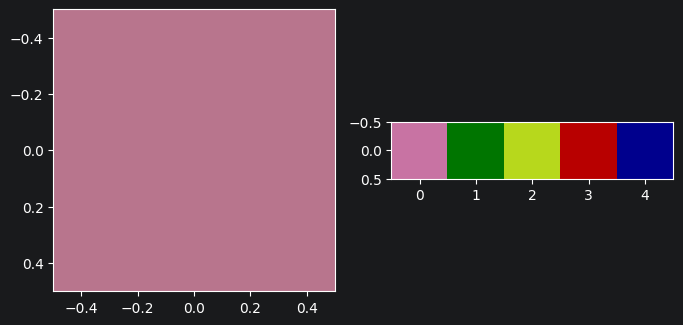

In [9]:
import matplotlib.pyplot as plt

# the main color
color1 = torch.rand(1, 1, 3)
# two random colors to mix with the main color channels
random_colors = torch.rand(1, 2, 3)

# we split the color channels and return the three channels as new colors
def split_rgb(t):
    r = torch.zeros_like(t)
    g = torch.zeros_like(t)
    b = torch.zeros_like(t)
    r[:, :, 0] = t[:, :, 0]
    g[:, :, 1] = t[:, :, 1]
    b[:, :, 2] = t[:, :, 2]
    return r, g, b

# add the main color channels to the random colors
color_sequence = torch.cat([random_colors, *split_rgb(color1)], dim=1)
# shuffle the colors
color_sequence = color_sequence[:, torch.randperm(color_sequence.shape[1]), :]

# show them
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
ax[0].imshow(color1)
ax[1].imshow(color_sequence)

plt.show()

Here we are building one data line. We can put this procedure in a function to generate multiple data lines.

In [10]:
from torch.utils.data import TensorDataset

def build_color_dataset(count, sequence_size=5):
    color1 = torch.rand(count, 1, 3)
    random_colors = torch.rand(count, sequence_size - 3, 3)

    color_channels = split_rgb(color1)
    color_sequence = torch.cat([random_colors, *color_channels], dim=1)
    color_sequence = color_sequence[:, torch.randperm(color_sequence.shape[1]), :]
    return TensorDataset(color1, color_sequence)

dataset = build_color_dataset(200)

Now we can build our color retrieval model. For this model we can create three filters that will get the individual channels from the main color and we compare each channel against the random color sequence to retrieve the best candidates. Then we can combine the retrieved channels to get the original colors. In this approach our loss function will be the error from the original color to the reconstructed color from the random sequence.

Since this is a simple problem we can infer what the ideal filters would be. One approach is having one in the channel we are looking at and zero everywhere else. But in language it is hard to know what the ideal filters are, so in this example we can see that our attention mechanismo will learn by itself the best filters to retrieve the relevant information. Let's start by the filters:

In [12]:
import torch.nn as nn

# sample from our dataset
color1, sequence = dataset[0]

filter1 = nn.Linear(3, 3)
filter2 = nn.Linear(3, 3)
filter3 = nn.Linear(3, 3)

q1 = filter1(color1)
q2 = filter2(color1)
q3 = filter3(color1)

print(q1)
print(q2)
print(q3)

tensor([[-0.1482,  0.3273,  0.0571]], grad_fn=<AddmmBackward0>)
tensor([[ 0.1730, -0.3569, -0.5265]], grad_fn=<AddmmBackward0>)
tensor([[ 0.5006, -0.4982,  0.6892]], grad_fn=<AddmmBackward0>)


Since our filters start by random weights, the retrieved information is not each color channel as we are expecting. Then we can compute the similarity of each channel to the random sequence to retrieve the components. At the beginning the retrieved color is wrong, but by applying backpropagation our model will learn to correctly find the promising filters. Those filters are called attention heads and the attention with multiple heads is called multi-head attention (MHA). In our example, we have 3 heads each one with 3 dimensions.

Now, for simplicity, let's use the distance formula instead of the dot product to compute the similarity since we don't need to compute the vector norms. Also, since our score is over 3 dimensions, the final score is the sum of the scores of each dimension:

$$ score = \sum_{i=1}^{3} \frac{1}{(q_i - c_i)^2 + 1} $$

Where $q_i$ is the output of the filter for the channel we are looking at and $c_i$ is the color channel from the random sequence. We can compute this score for each filter and each color in the random sequence to retrieve the best candidates for each channel.

In [16]:
def compute_score(color, sequence):
    score = 1 / ((color - sequence) ** 2 + 1)
    return torch.sum(score, dim=-1)

score1 = compute_score(q1, sequence)
score2 = compute_score(q2, sequence)
score3 = compute_score(q3, sequence)

print(score1)
print(score2)
print(score3)

tensor([2.6325, 2.7957, 2.8604, 2.7010, 2.9743], grad_fn=<SumBackward1>)
tensor([2.1656, 2.6696, 2.5095, 2.3973, 2.4156], grad_fn=<SumBackward1>)
tensor([2.2947, 2.3927, 2.4106, 2.5687, 2.0545], grad_fn=<SumBackward1>)


Now we get the color with highest score in each channel and combine them to produce the final color.

In [23]:
print(score1.argmax(), score2.argmax(), score3.argmax())

best_color1 = sequence[score1.argmax(), :]
best_color2 = sequence[score2.argmax(), :]
best_color3 = sequence[score3.argmax(), :]

final_color = best_color1 + best_color2 + best_color3
print('Main color:\n', color1)
print('Reconstructed color:\n', final_color)

tensor(4) tensor(1) tensor(3)
Main color:
 tensor([[0.1931, 0.3581, 0.2047]])
Reconstructed color:
 tensor([0.5539, 0.4635, 0.2774])


Now we can put everything into a multi head attention class to start our training. However, we have some important points to consider before starting the training. First of all, let's take a look at the argmax gradient:

In [26]:
p1 = color1.clone()
p1.requires_grad = True

# show the grad_fn since our color now requires grad
print(p1 + 1)

score = compute_score(p1, sequence)
# our score also have a grad_fn
print(score)

# now the argmax
print(score.argmax())

tensor([[1.1931, 1.3581, 1.2047]], grad_fn=<AddBackward0>)
tensor([2.8559, 2.8461, 2.8504, 2.9074, 2.9238], grad_fn=<SumBackward1>)
tensor(4)


And here is the problem. The argmax function is not differentiable. This means that we can't backpropagate the error from the final color to the filters weights. We need to use a diferentiable argmax function. And the alternative is to use the soft argmax function that gives us a higher value at the index of the max value and lower values everywere else. This function is the softmax function we applyed in previous chapters to compute the probability distribution over the next tokens. Since the softmax adds to 1 it follows to rules of a probability distribution and also gives us the soft version of the argmax that is diferentiable.

Then, using softmax we will have a weighted sum over the sequence colors instead of getting only the maximum score color. Since we will use this attention for other purposes, the color we are searching for is called query, the sequence of colors we are searching for is the keys and the colors we are retrieving by multiplying the scores by the sequence colors are called values. In our case, the keys and values are the same but in other applications is possible that we search using one criteria that is different from the information we are retrieving.

With the softmax attention scores we can use it to compute our final color. Before that we need just to change our score function to add a small value $\beta$ to avoid division by zero instead of 1 since we have now higher values to work with the softmax function:

$$ score = \sum_{i=1}^{n_{dim}} \frac{1}{(q_i - c_i)^2 + \beta} $$

Another improvement is that if we need to add more channels we don't want to write more code to compute the extra head scores. So we will join multiple channels in one weight to compute then in parallel with the same code. Putting everything together we have the MHA class:

In [29]:
class MHA(nn.Module):
    def __init__(self, heads=1, n_dim=1, beta=0.1):
        super(MHA, self).__init__()
        # we join the heads in one weight to compute them in parallel
        self.filter = nn.Linear(n_dim, heads * n_dim)
        self.heads = heads
        self.n_dim = n_dim
        self.beta = beta

    def forward(self, x, y, return_score=False):
        # by applying the filters to the color we are searching for we have the query
        query = self.filter(x)

        # splitting the heads into a new dimension
        split_query = torch.unflatten(query, 2, (-1, self.n_dim))
        # we add another dimension in the sequence colors for broadcasting
        split_keys = y.unsqueeze(-2)

        # now we rearrange our dimensions to move the head dimension near to the batch dimension
        # before (batch, sequence, head, dims) after (batch, head, sequence, dim)
        split_query = split_query.permute(0, 2, 1, 3)
        split_keys = split_keys.permute(0, 2, 1, 3)

        # computing the attention scores using our score function
        attention_score = 1 / (torch.sum(torch.pow(split_query - split_keys, 2), dim=-1) + self.beta)

        # no derivative for argmax, use soft argmax instead (softmax)
        attention_score = torch.softmax(attention_score, dim=-1)

        # our values are equal to the keys
        split_values = y.unsqueeze(1)

        # weighted sum
        out = attention_score.unsqueeze(-1) * split_values
        # combine all the heads
        head_sum = torch.sum(out, dim=-2)
        # combine the colors in the sequence to have the final color
        sequence_sum = torch.sum(head_sum, dim=1, keepdim=True)

        # return the attention matrix for debbuging
        if return_score:
            return sequence_sum, attention_score
        else:
            return sequence_sum

Now we can start the training of our MHA model. We will use the mean squared error loss between the original color and the reconstructed color to train our model. We will also plot the loss curve to see how our model is learning.

  0%|          | 0/60000 [00:00<?, ?it/s]

0.00040566520028588704


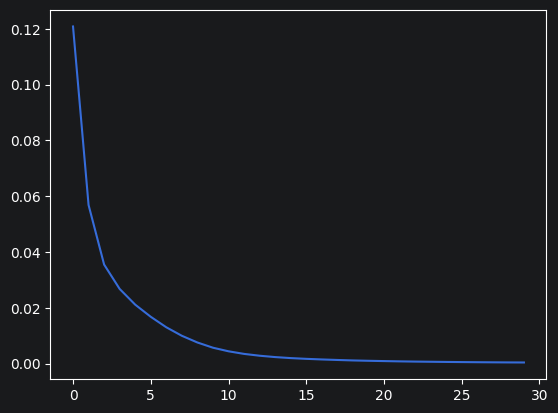

In [31]:
from torch.utils.data import DataLoader
import torch.optim as optim
from tqdm.auto import tqdm


def train(model, data, epochs=10, lr=0.001, batch_size=16):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    progress = tqdm(total=len(data) * epochs)
    lh = []
    for epoch in range(epochs):
        el = []
        for (x, y) in DataLoader(data, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            out = model(x, y)
            loss = crit(out, x)
            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])
        lh.append(sum(el) / len(el))

    progress.close()
    return lh


mha = MHA(heads=3, n_dim=3)
dataset = build_color_dataset(2000)
lh = train(mha, dataset, epochs=30, lr=0.001, batch_size=32)
# last loss
print(lh[-1])
plt.plot(lh)

plt.show()

In [32]:
c1, c2 = dataset[0]
print(c1)
print(mha(c1.unsqueeze(0), c2.unsqueeze(0)))

tensor([[0.3698, 0.8627, 0.3206]])
tensor([[[0.3868, 0.8508, 0.3284]]], grad_fn=<SumBackward1>)


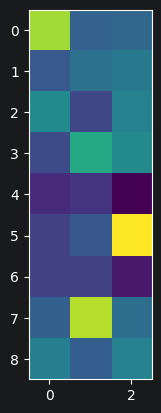

In [34]:
plt.imshow(mha.filter.weight.data)
plt.show()

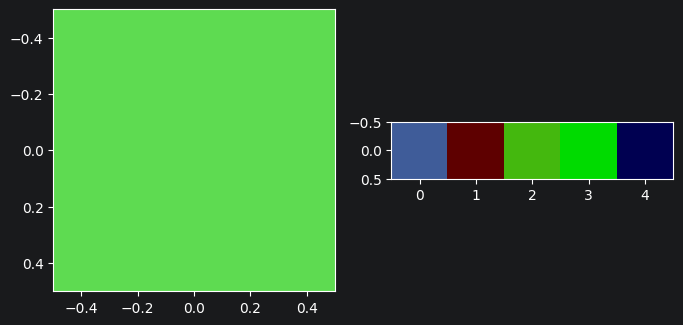

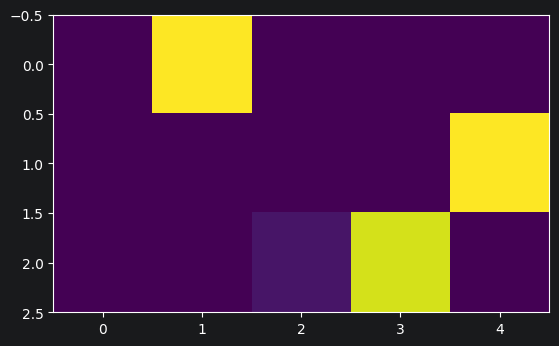

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
ax[0].imshow(c1.unsqueeze(0))
ax[1].imshow(c2.unsqueeze(0))
plt.show()

o, a = mha(c1.unsqueeze(0), c2.unsqueeze(0), return_score=True)

plt.imshow(a.detach().squeeze(0))
plt.show()

In [13]:
class MHA(nn.Module):
    def __init__(self):
        super(MHA, self).__init__()
        self.q = nn.Linear(3, 3, bias=False)

    def forward(self, x, y, at=False):
        q = self.q(x)
        hq = torch.unflatten(q, 2, (-1, 1)).permute(0, 2, 1, 3)
        hy = torch.unflatten(y, 2, (-1, 1)).permute(0, 2, 1, 3)
        a = 1 / (torch.sum(torch.pow(hy - hq, 2), dim=-1) + 0.01)
        a = torch.softmax(a, dim=-1)
        o = a.unsqueeze(-1) * hy
        out = torch.sum(o, dim=-2, keepdim=True) / torch.sum(a.unsqueeze(-1), dim=-2, keepdim=True)
        out = out.permute(0, 2, 1, 3).flatten(2)
        if not at:
            return out
        else:
            return out, a


mha = MHA()

for (x, y) in DataLoader(dataset, batch_size=1, shuffle=True):
    print(x.shape, mha(x, y).shape)
    break

torch.Size([1, 1, 3]) torch.Size([1, 1, 3])


  0%|          | 0/400000 [00:00<?, ?it/s]

0.03306810129138212


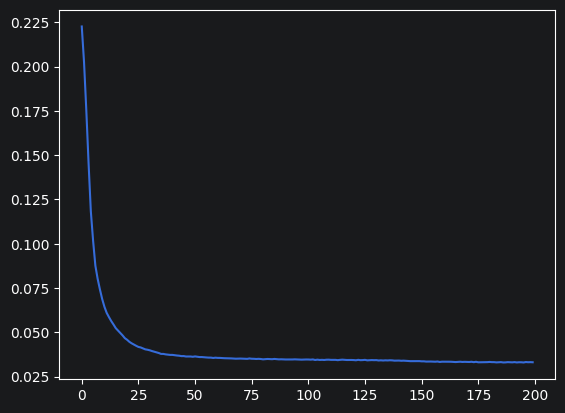

In [14]:
mha = MHA()
lh = train(mha, dataset, epochs=200, lr=0.001, batch_size=32)
print(lh[-1])
plt.plot(lh)
plt.show()

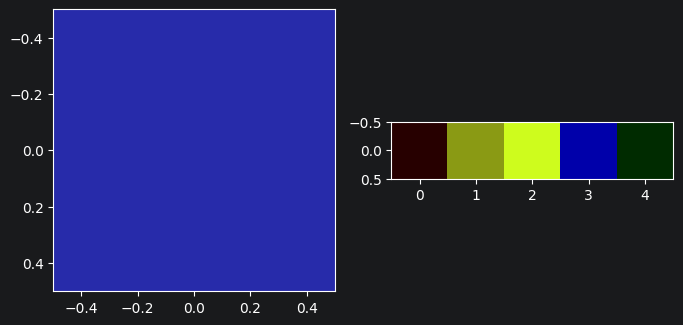

tensor([[0.1548, 0.1705, 0.6695]])
tensor([[[0.1548, 0.2611, 0.6695]]], grad_fn=<ViewBackward0>)


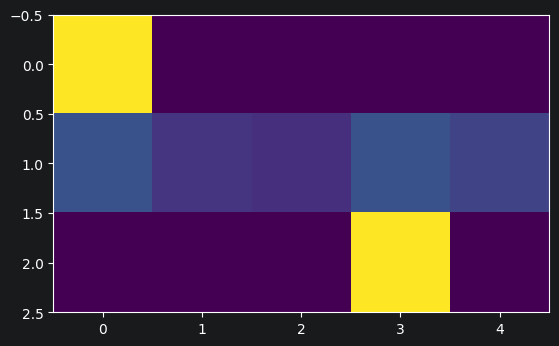

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
ax[0].imshow(c1.unsqueeze(0))
ax[1].imshow(c2.unsqueeze(0))
plt.show()

o, a = mha(c1.unsqueeze(0), c2.unsqueeze(0), at=True)
print(c1)
print(o)
plt.imshow(a.detach().squeeze(0))
plt.show()

In [16]:
wi = {
    'S': 0,
    'a': 1,
    'b': 2,
    'c': 3,
    'd': 4,
    'X': 5,
    'Y': 6,
    'E': 7,
    '-': 8
}

In [17]:
import random

In [18]:
def gen_seq():
    fs = ['S']
    for _ in range(random.randint(4, 10)):
        fs.append(random.choice('abcd'))

    f1 = random.randint(1, len(fs) - 2)
    f2 = random.randint(f1, len(fs) - 1)

    rc1 = random.choice('XY')
    rc2 = random.choice('XY')

    fs[f1] = rc1
    fs[f2] = rc2

    fs.append('E')

    r = {
        'XX': 0,
        'XY': 1,
        'YX': 2,
        'YY': 3
    }
    return ''.join(fs), r[rc1 + rc2]


s, q = gen_seq()
print(s, q)

SXaXdE 0


In [19]:
class MHA(nn.Module):
    def __init__(self, n_dim=16, heads=2):
        super(MHA, self).__init__()
        self.q = nn.Linear(n_dim, n_dim, bias=False)
        self.k = nn.Linear(n_dim, n_dim, bias=False)
        self.v = nn.Linear(n_dim, n_dim, bias=False)
        self.o = nn.Linear(n_dim, n_dim, bias=False)

        self.n_dim = n_dim
        self.heads = heads
        self.head_dim = n_dim // heads

    def forward(self, x, at=False):
        q = self.q(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        k = self.k(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 3, 1)

        a = q @ k
        a /= math.sqrt(self.n_dim)
        # todo apply padding mask
        a = torch.softmax(a, dim=-1)

        v = self.v(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        o = a @ v
        o = o.permute(0, 2, 1, 3).flatten(2)
        if not at:
            return self.o(o)
        else:
            return self.o(o), a


emb = nn.Embedding(9, 4)
mha = MHA(n_dim=4, heads=2)

q1 = torch.LongTensor([wi[c] for c in 'SaXbYcE'])
q2 = torch.LongTensor([wi[c] for c in 'SaYbXcE'])

e1 = emb(q1).unsqueeze(0)
e2 = emb(q2).unsqueeze(0)

o1 = mha(e1)
o2 = mha(e2)

print(torch.isclose(o1[:, -1], o2[:, -1]).all())

tensor(True)


In [20]:
emb = nn.Embedding(9, 4)
q1 = torch.LongTensor([wi[c] for c in 'SaXbYcE'])
print(torch.arange(1, q1.shape[0]).unsqueeze(0).repeat(4, 1))

tensor([[1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6]])


In [21]:
def binary(x, bits):
    mask = 2 ** torch.arange(bits - 1, -1, -1).to(x.device, x.dtype)
    return x.unsqueeze(-1).bitwise_and(mask).ne(0).float()


e = emb(q1)
be = binary(torch.arange(1, e.shape[0] + 1), 4)
enc = e + be
print(enc)

tensor([[-0.1912,  0.0160,  0.1292,  2.1190],
        [ 0.8907,  0.2460,  1.1696, -1.6813],
        [ 0.6354, -0.6394, -0.7150,  0.5192],
        [ 0.2804,  0.8050,  1.6977,  0.5917],
        [-0.9176,  1.8054,  0.0462,  1.7322],
        [ 2.6019,  0.5688, -0.1659, -1.0338],
        [ 1.0218,  2.1314,  1.6563,  0.4344]], grad_fn=<AddBackward0>)


In [22]:
emb = nn.Embedding(9, 4)
mha = MHA(n_dim=4, heads=2)

q1 = torch.LongTensor([wi[c] for c in 'SaXbYcE'])
q2 = torch.LongTensor([wi[c] for c in 'SaYbXcE'])

be = binary(torch.arange(1, len(q1) + 1), 4)

e1 = emb(q1).unsqueeze(0) + be
e2 = emb(q2).unsqueeze(0) + be

o1 = mha(e1)
o2 = mha(e2)

print(torch.isclose(o1[:, -1], o2[:, -1]).all())

tensor(False)


In [23]:
def seq_data(n):
    seqs = []
    labels = []
    for _ in range(n):
        s, q = gen_seq()
        seqs.append(s)
        labels.append(q)

    seqs = [[wi[c] for c in s] for s in seqs]
    ml = max([len(s) for s in seqs])
    em = torch.LongTensor([len(s) - 1 for s in seqs])
    seqs = [q + [wi['-']] * (ml - len(q)) for q in seqs]
    return TensorDataset(torch.LongTensor(seqs), em, torch.LongTensor(labels))


dataset = seq_data(500)

In [24]:
class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)
        self.mha = MHA(n_dim, n_head)
        self.lm = nn.Sequential(
            nn.Linear(n_dim, 4),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim

    def forward(self, x):
        pos = binary(torch.arange(1, x.shape[1] + 1), self.n_dim)
        e = self.emb(x) + pos
        mha = self.mha(e)
        return self.lm(mha)

  0%|          | 0/50000 [00:00<?, ?it/s]

0.26626296527683735


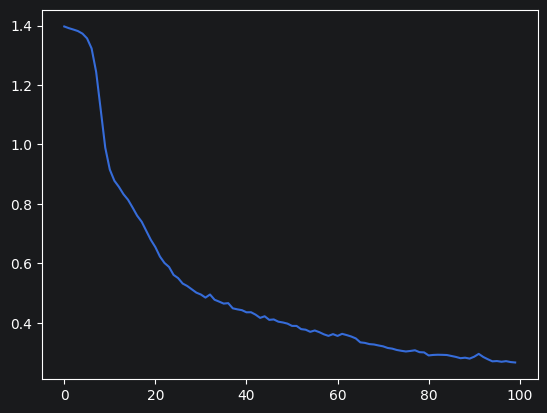

In [25]:
def train_model(model, data, epochs=10, lr=0.001, batch_size=16):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss()
    progress = tqdm(total=len(data) * epochs)
    lh = []
    for epoch in range(epochs):
        el = []
        for (x, em, y) in DataLoader(data, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            out = model(x)
            loss = crit(out[torch.arange(x.shape[0]), em], y)
            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])
        lh.append(sum(el) / len(el))

    progress.close()
    return lh


model = Model(vocab_size=9, n_dim=8, n_head=2)
lh = train_model(model, dataset, epochs=100, lr=0.001, batch_size=32)
print(lh[-1])
plt.plot(lh)
plt.show()

In [26]:
q1 = torch.LongTensor([[wi[c] for c in 'SaXbYcE']])
q2 = torch.LongTensor([[wi[c] for c in 'SaYbXcE']])

model.eval()
with torch.no_grad():
    o1 = model(q1)
    o2 = model(q2)

r = {
    'XX': 0,
    'XY': 1,
    'YX': 2,
    'YY': 3
}

print(o1[:, -1].argmax())
print(o2[:, -1].argmax())


tensor(1)
tensor(2)


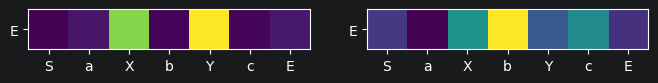

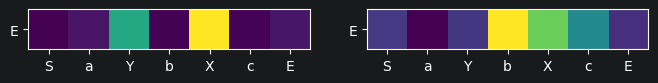

In [27]:
def plot_at(at, ticks):
    fig, ax = plt.subplots(1, 2, figsize=(8, 5))

    ax[0].imshow(at[0, -1, :].unsqueeze(0))

    ax[0].set_xticks(range(len(ticks)))
    ax[0].set_xticklabels(ticks)
    ax[0].set_yticks([0])
    ax[0].set_yticklabels(['E'])
    ax[1].imshow(at[1, -1, :].unsqueeze(0))
    ax[1].set_xticks(range(len(ticks)))
    ax[1].set_xticklabels(ticks)
    ax[1].set_yticks([0])
    ax[1].set_yticklabels(['E'])
    plt.show()


pos = binary(torch.arange(1, q1.shape[1] + 1), model.n_dim)

with torch.no_grad():
    e1 = model.emb(q1) + pos
    o, a1 = model.mha(e1, at=True)

    e2 = model.emb(q2) + pos
    o, a2 = model.mha(e2, at=True)

at1 = a1.squeeze(0)
at2 = a2.squeeze(0)

ticks1 = 'SaXbYcE'
ticks2 = 'SaYbXcE'

plot_at(at1, ticks1)
plot_at(at2, ticks2)


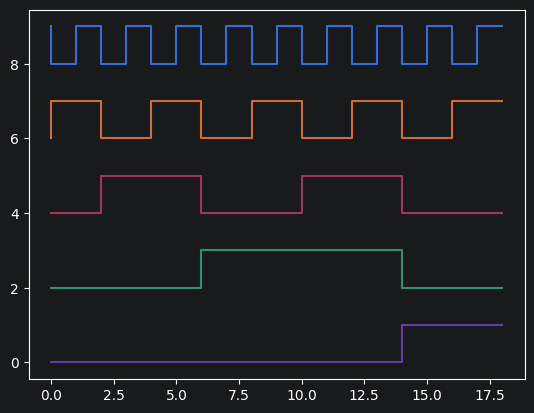

In [28]:
be = binary(torch.arange(1, 20), 5)
be = be + torch.arange(5).unsqueeze(0) * 2
for s in torch.flip(be, dims=[1]).T:
    plt.step(torch.arange(s.shape[0]), s)
plt.show()

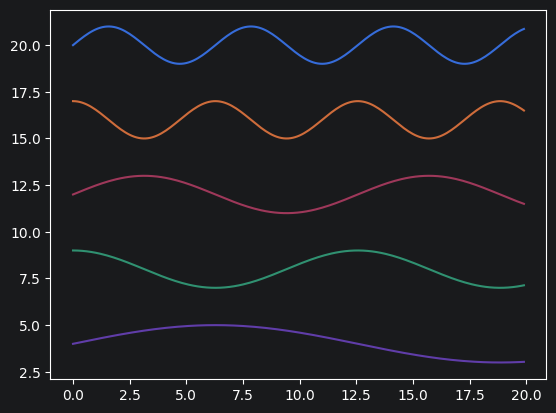

In [29]:
x = torch.arange(0, 20, 0.1)

for i in range(5):

    if i % 2 == 0:
        t = x / (2 ** (2 * i / 4))
        st = torch.sin(t)
    else:
        t = x / (2 ** (2 * (i - 1) / 4))
        st = torch.cos(t)

    plt.plot(x, (5 - i) * 4 + st)
plt.show()

In [30]:
def pos_encode(max_len, d_model, base=10000.0):
    position = torch.arange(max_len).unsqueeze(1)

    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(base) / d_model))

    pe = torch.zeros(max_len, d_model)

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe



  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

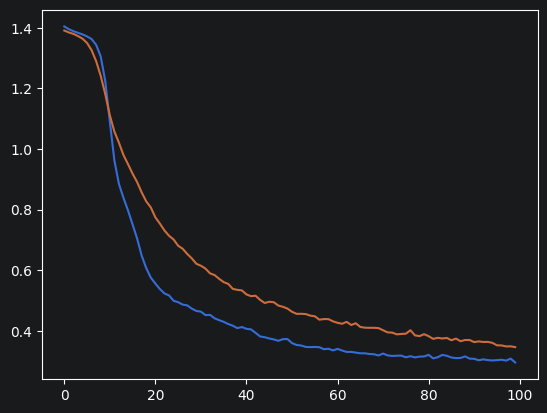

In [31]:
class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, use_pos=True, max_len=20):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)
        self.mha = MHA(n_dim, n_head)
        self.lm = nn.Sequential(
            nn.Linear(n_dim, 4),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim
        self.pos = nn.Parameter(pos_encode(max_len, n_dim, base=2), requires_grad=False)
        self.use_pos = use_pos

    def forward(self, x):
        if not self.use_pos:
            pos = binary(torch.arange(1, x.shape[1] + 1), self.n_dim)
        else:
            pos = self.pos[:x.shape[1], :]
        e = self.emb(x) + pos
        mha = self.mha(e)
        return self.lm(mha)


model = Model(vocab_size=9, n_dim=8, n_head=2, use_pos=False)
lh = train_model(model, dataset, epochs=100, lr=0.001, batch_size=32)
plt.plot(lh)
model = Model(vocab_size=9, n_dim=8, n_head=2, use_pos=True)
lh = train_model(model, dataset, epochs=100, lr=0.001, batch_size=32)
plt.plot(lh)
plt.show()


In [32]:
wi = {
    'S': 0,
    'a': 1,
    'b': 2,
    'c': 3,
    'd': 4,
    'A': 5,
    'B': 6,
    'C': 7,
    'D': 8,
    'X': 9,
    'Y': 10,
    'E': 11,
    '-': 12,
    '^': 13
}

iw = {v: k for k, v in wi.items()}

In [33]:
def gen_up_seq(n=15):
    r = ''
    for _ in range(random.randint(1, (n - 3) // 2)):
        r += random.choice('abcdABCD')

    return f'S{r}^{r.upper()}E'


def gen_up_data(n, l=15, token=True):
    seqs = []
    for _ in range(n):
        s = gen_up_seq(l)
        seqs.append(s)

    if not token:
        return seqs

    lm = [[0] * s.index('^') + [1] * (len(s) - s.index('^') - 1) + [1] for s in seqs]
    seqs = [[wi[c] for c in s] for s in seqs]
    ml = max([len(s) for s in seqs])
    am = [[1] * len(s) + [0] * (ml - len(s)) for s in seqs]
    lm = [s + [0] * (ml - len(s)) for s in lm]
    seqs = [q + [wi['-']] * (ml - len(q)) for q in seqs]
    return TensorDataset(torch.LongTensor(seqs), torch.Tensor(am), torch.Tensor(lm))


data = gen_up_data(1000, 20)
test = gen_up_data(50, 20, token=False)



In [34]:
x, m, lm = data[0]
print([iw[q.item()] for q in x])
print(x)
print(m)
print(lm)

['S', 'A', 'b', 'A', 'A', 'B', 'A', '^', 'A', 'B', 'A', 'A', 'B', 'A', 'E', '-', '-', '-', '-']
tensor([ 0,  5,  2,  5,  5,  6,  5, 13,  5,  6,  5,  5,  6,  5, 11, 12, 12, 12,
        12])
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.,
        0.])
tensor([0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.,
        0.])


In [35]:
class MHA(nn.Module):
    def __init__(self, n_dim=16, heads=2):
        super(MHA, self).__init__()
        self.q = nn.Linear(n_dim, n_dim, bias=False)
        self.k = nn.Linear(n_dim, n_dim, bias=False)
        self.v = nn.Linear(n_dim, n_dim, bias=False)
        self.o = nn.Linear(n_dim, n_dim, bias=False)

        self.n_dim = n_dim
        self.heads = heads
        self.head_dim = n_dim // heads

    def forward(self, x, m=None, at=False):
        q = self.q(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        k = self.k(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 3, 1)

        a = q @ k
        a /= math.sqrt(self.head_dim)

        if m is not None:
            pm = torch.logical_not(m).unsqueeze(1).repeat(1, a.shape[-1], 1).unsqueeze(1)
            cm = torch.triu(torch.ones(a.shape[-2], a.shape[-1]), diagonal=1).unsqueeze(0).unsqueeze(0)
            fm = torch.logical_or(pm, cm)
        else:
            fm = torch.triu(torch.ones(a.shape[-2], a.shape[-1]), diagonal=1).bool()

        a = torch.masked_fill(a, fm, -1e6)
        a = torch.softmax(a, dim=-1)
        a = torch.dropout(a, 0.1, train=self.training)

        v = self.v(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        o = a @ v
        o = o.permute(0, 2, 1, 3).flatten(2)
        if not at:
            return self.o(o)
        else:
            return self.o(o), a

# mha = MHA(n_dim=4, heads=2)
# emb = nn.Embedding(len(wi), 4)
# q1 = torch.LongTensor([wi[c] for c in 'SaXb'])
#
# mha(emb(q1).unsqueeze(0), torch.Tensor([[1, 1, 0, 0]])).shape

In [36]:

class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, max_len=20):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)

        self.mha = MHA(n_dim, n_head)

        self.lm = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim
        self.pos = nn.Parameter(pos_encode(max_len, n_dim, base=2), requires_grad=False)

    def forward(self, x, m=None):
        pos = self.pos[:x.shape[1], :]
        e = self.emb(x) + pos
        e = self.mha(e, m)
        return self.lm(e)

    def gen(self, s, max_len=10, bs=16):
        self.eval()

        ml = max([len(q) for q in s])
        at = [[1] * len(q) for q in s]
        s = ['-' * (ml - len(q)) + q for q in s]
        s = [[wi[q] for q in w] for w in s]
        at = [[0] * (ml - len(q)) + q for q in at]

        st = torch.LongTensor(s)
        at = torch.Tensor(at)

        res = []

        for x, m in DataLoader(TensorDataset(st, at), batch_size=bs, shuffle=False):
            for _ in range(max_len):
                with torch.no_grad():
                    o = self(x, m)
                    ne = o.exp().argmax(dim=-1)[:, -1].unsqueeze(1)
                    x = torch.cat([x, ne], dim=1)
                    m = torch.cat([m, torch.ones(m.shape[0], 1)], dim=1)
            res.append(x)

        fr = torch.cat(res, dim=0)
        fres = []
        for q in fr:
            fres.append(''.join([iw[c] for c in q.tolist()]))

        return fres

  0%|          | 0/100000 [00:00<?, ?it/s]

0.3142410535365343


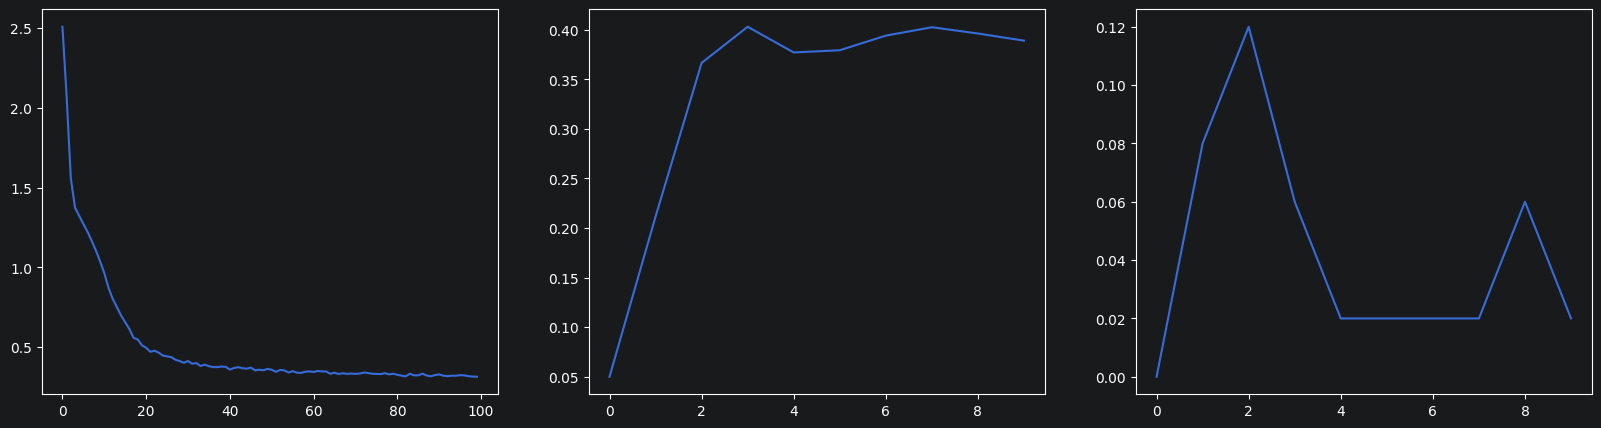

In [37]:
def test_model(model, test, max_len=10):
    ft = []
    r = []
    for t in test:
        q1, q2 = t.split('^')
        ft.append(q1 + '^')
        r.append(q2)

    o = model.gen(ft, max_len=max_len)
    fr = []
    ps = []
    for o0, r0 in zip(o, r):
        so = o0.split('^')[-1].split('E')[0] + 'E'
        sr = r0
        ml = max(len(so), len(sr))

        p1 = so + '-' * (ml - len(so))
        p2 = sr + '-' * (ml - len(sr))

        m = [1 if q == w else 0 for q, w in zip(p1, p2)]
        fr.extend(m)
        ps.append(1 if sum(m) == len(m) else 0)

    return sum(fr) / len(fr), sum(ps) / len(ps)


def lm_train(model, data_train, data_test=None, epochs=100, lr=0.001, batch_size=32, test_every=10, max_len=20):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss(reduction='none')
    progress = tqdm(total=len(data_train) * epochs)
    lh = []
    tl = []
    for epoch in range(epochs):
        model.train()
        el = []
        for (x, m, lm) in DataLoader(data_train, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            out = model(x, m)
            loss = crit(torch.flatten(out[:, :-1], start_dim=0, end_dim=1), x[:, 1:].flatten())
            loss = torch.sum(loss * lm[:, :-1].flatten()) / torch.sum(lm[:, :-1])

            loss.backward()
            el.append(loss.item())
            optimizer.step()
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))
        if data_test is not None and epoch % test_every == 0:
            tl.append(test_model(model, data_test, max_len=max_len))
    progress.close()
    return lh, tl


model = Model(vocab_size=len(wi), n_dim=32, n_head=4, max_len=40)
lh, tl = lm_train(model, data, test, epochs=100, lr=0.001, batch_size=64, max_len=20)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

print(lh[-1])
ax[0].plot(lh)
l1, l2 = zip(*tl)
ax[1].plot(l1)
ax[2].plot(l2)
plt.show()

In [38]:

def rope_rotate(x, frec):
    uf = frec.unsqueeze(1).unsqueeze(-1)
    uf = uf[:, :, :x.shape[2], :]

    p1 = x[:, :, :, :, 0]
    p2 = x[:, :, :, :, 1]
    nx1 = p1 * torch.cos(uf) - p2 * torch.sin(uf)
    nx2 = p1 * torch.sin(uf) + p2 * torch.cos(uf)

    return torch.cat([nx1.unsqueeze(-1), nx2.unsqueeze(-1)], dim=-1)


def apply_rope(x, frec):
    fx = frec
    fv = x.unflatten(-1, (-1, 2))
    rx = rope_rotate(fv, fx)
    return rx.flatten(-2)

In [39]:
class RMHA(nn.Module):
    def __init__(self, n_dim=16, heads=2):
        super(RMHA, self).__init__()
        self.q = nn.Linear(n_dim, n_dim, bias=False)
        self.k = nn.Linear(n_dim, n_dim, bias=False)
        self.v = nn.Linear(n_dim, n_dim, bias=False)
        self.o = nn.Linear(n_dim, n_dim, bias=False)

        self.n_dim = n_dim
        self.heads = heads
        self.head_dim = n_dim // heads

    def forward(self, x, m=None, freq=None, at=False):
        q = self.q(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        k = self.k(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)

        if freq is not None:
            q = apply_rope(q, freq)

            k = apply_rope(k, freq)

        a = q @ k.permute(0, 1, 3, 2)
        a /= math.sqrt(self.head_dim)

        if m is not None:
            pm = torch.logical_not(m).unsqueeze(1).repeat(1, a.shape[-1], 1).unsqueeze(1)
            cm = torch.triu(torch.ones(a.shape[-2], a.shape[-1]), diagonal=1).unsqueeze(0).unsqueeze(0)
            fm = torch.logical_or(pm, cm)
        else:
            fm = torch.triu(torch.ones(a.shape[-2], a.shape[-1]), diagonal=1).bool()

        a = torch.masked_fill(a, fm, -1e6)
        a = torch.softmax(a, dim=-1)
        a = torch.dropout(a, 0.1, train=self.training)

        v = self.v(x).unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        o = a @ v
        o = o.permute(0, 2, 1, 3).flatten(2)
        if not at:
            return self.o(o)
        else:
            return self.o(o), a


mha = RMHA(n_dim=8, heads=2)
emb = nn.Embedding(len(wi), 8)
q1 = torch.LongTensor([wi[c] for c in 'SaXb'])

pa = torch.arange(0, 2)
freq_size = torch.arange(0, 8 // 2 // 2)
base_frecs = 1.0 / torch.pow(20, 2 * freq_size / 8)

fx = torch.flatten(pa.unsqueeze(-1) * base_frecs, end_dim=1).unsqueeze(0)

mha(emb(q1).unsqueeze(0), torch.Tensor([[1, 1, 0, 0]]), fx).shape

torch.Size([1, 4, 8])

In [40]:

class TL(nn.Module):
    def __init__(self, n_dim, n_head):
        super(TL, self).__init__()
        self.mha = RMHA(n_dim, n_head)

    def forward(self, x, m=None, freq=None, at=False):
        e = self.mha(x, m, freq)
        return e


class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, layers=2, max_len=20):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)

        self.tl = nn.ModuleList([TL(n_dim, n_head) for _ in range(layers)])

        self.lm = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim

        pa = torch.arange(0, max_len)
        freq_size = torch.arange(0, n_dim // n_head // 2)
        base_frecs = 1.0 / torch.pow(20, 2 * freq_size / n_dim)

        self.fx = torch.flatten(pa.unsqueeze(-1) * base_frecs, end_dim=1).unsqueeze(0)

    def forward(self, x, m=None):
        e = self.emb(x)
        for tl in self.tl:
            e = tl(e, m, self.fx)
        return self.lm(e)

    def gen(self, s, max_len=10, bs=16):
        self.eval()

        ml = max([len(q) for q in s])
        at = [[1] * len(q) for q in s]
        s = ['-' * (ml - len(q)) + q for q in s]
        s = [[wi[q] for q in w] for w in s]
        at = [[0] * (ml - len(q)) + q for q in at]

        st = torch.LongTensor(s)
        at = torch.Tensor(at)

        res = []

        for x, m in DataLoader(TensorDataset(st, at), batch_size=bs, shuffle=False):
            for _ in range(max_len):
                with torch.no_grad():
                    o = self(x, m)
                    ne = o.exp().argmax(dim=-1)[:, -1].unsqueeze(1)
                    x = torch.cat([x, ne], dim=1)
                    m = torch.cat([m, torch.ones(m.shape[0], 1)], dim=1)
            res.append(x)

        fr = torch.cat(res, dim=0)
        fres = []
        for q in fr:
            fres.append(''.join([iw[c] for c in q.tolist()]))

        return fres

  0%|          | 0/100000 [00:00<?, ?it/s]

0.2590952292084694


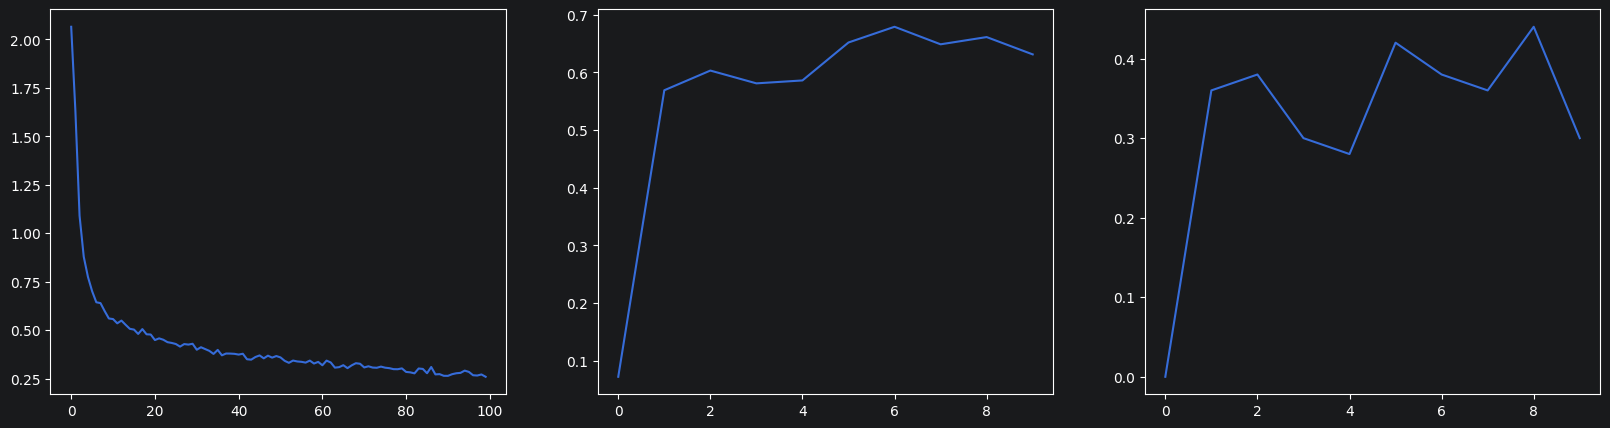

In [41]:
model = Model(vocab_size=len(wi), n_dim=128, n_head=8, layers=2, max_len=40)
lh, tl = lm_train(model, data, test, epochs=100, lr=0.001, batch_size=64, max_len=20)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

print(lh[-1])
ax[0].plot(lh)
l1, l2 = zip(*tl)
ax[1].plot(l1)
ax[2].plot(l2)
plt.show()

In [42]:
print(model.gen(['Sabc^', 'SaABcd^', 'Sbbbb^'], max_len=20))

['--Sabc^ABCE--------------A-', 'SaABcd^AABCDE------------A-', '-Sbbbb^BBBE--------------B-']


In [43]:
wi = {
    'S': 0,
    'a': 1,
    'b': 2,
    'c': 3,
    'd': 4,
    'A': 5,
    'B': 6,
    'C': 7,
    'D': 8,
    'X': 9,
    'Y': 10,
    'E': 11,
    '-': 12,
    '^': 13,
    'v': 14,
    '<': 15,
    '=': 16
}

iw = {v: k for k, v in wi.items()}

In [44]:
def gen_up_seq(n=15):
    r = ''
    for _ in range(random.randint(1, (n - 3) // 2)):
        r += random.choice('abcdABCD')

    t = random.randint(0, 3)

    if t == 0:
        return f'S{r}^{r.upper()}E', '^'
    elif t == 1:
        return f'S{r}v{r.lower()}E', 'v'
    elif t == 2:
        rs = ''.join(reversed(r))
        return f'S{r}<{rs}E', '<'
    elif t == 3:
        return f'S{r}={r}E', '='

    return None, None


def gen_up_data(n, l=15, token=True):
    seqs = []
    ks = []
    for _ in range(n):
        s, k = gen_up_seq(l)
        seqs.append(s)
        ks.append(k)

    if not token:
        return seqs, ks


    lm = [[0] * s.index(k) + [1] * (len(s) - s.index(k) - 1) + [1] for s, k in zip(seqs, ks)]
    seqs = [[wi[c] for c in s] for s in seqs]

    ml = max([len(s) for s in seqs])
    am = [[1] * len(s) + [0] * (ml - len(s)) for s in seqs]
    lm = [s + [0] * (ml - len(s)) for s in lm]
    seqs = [q + [wi['-']] * (ml - len(q)) for q in seqs]
    return TensorDataset(torch.LongTensor(seqs), torch.Tensor(am), torch.Tensor(lm))


data = gen_up_data(2000, 20)
test = gen_up_data(50, 20, token=False)



In [45]:
def test_model(model, test, max_len=10):
    ft = []
    r = []
    ks = []
    for t, k in zip(*test):
        q1, q2 = t.split(k)
        ft.append(q1 + k)
        r.append(q2)
        ks.append(k)

    o = model.gen(ft, max_len=max_len)
    fr = []
    ps = []
    for o0, r0, k in zip(o, r, ks):
        so = o0.split(k)[-1].split('E')[0] + 'E'
        sr = r0
        ml = max(len(so), len(sr))

        p1 = so + '-' * (ml - len(so))
        p2 = sr + '-' * (ml - len(sr))

        m = [1 if q == w else 0 for q, w in zip(p1, p2)]
        fr.extend(m)
        ps.append(1 if sum(m) == len(m) else 0)

    return sum(fr) / len(fr), sum(ps) / len(ps)


def lm_train(model, data_train, data_test=None, epochs=100, lr=0.001, batch_size=32, test_every=10, max_len=20):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss(reduction='none')
    progress = tqdm(total=len(data_train) * epochs)
    lh = []
    tl = []
    for epoch in range(epochs):
        model.train()
        el = []
        for (x, m, lm) in DataLoader(data_train, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            out = model(x, m)
            loss = crit(torch.flatten(out[:, :-1], start_dim=0, end_dim=1), x[:, 1:].flatten())
            loss = torch.sum(loss * lm[:, :-1].flatten()) / torch.sum(lm[:, :-1])

            loss.backward()
            el.append(loss.item())
            optimizer.step()
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))
        if data_test is not None and epoch % test_every == 0:
            tl.append(test_model(model, data_test, max_len=max_len))
    progress.close()
    return lh, tl

  0%|          | 0/200000 [00:00<?, ?it/s]

0.4597483593970537


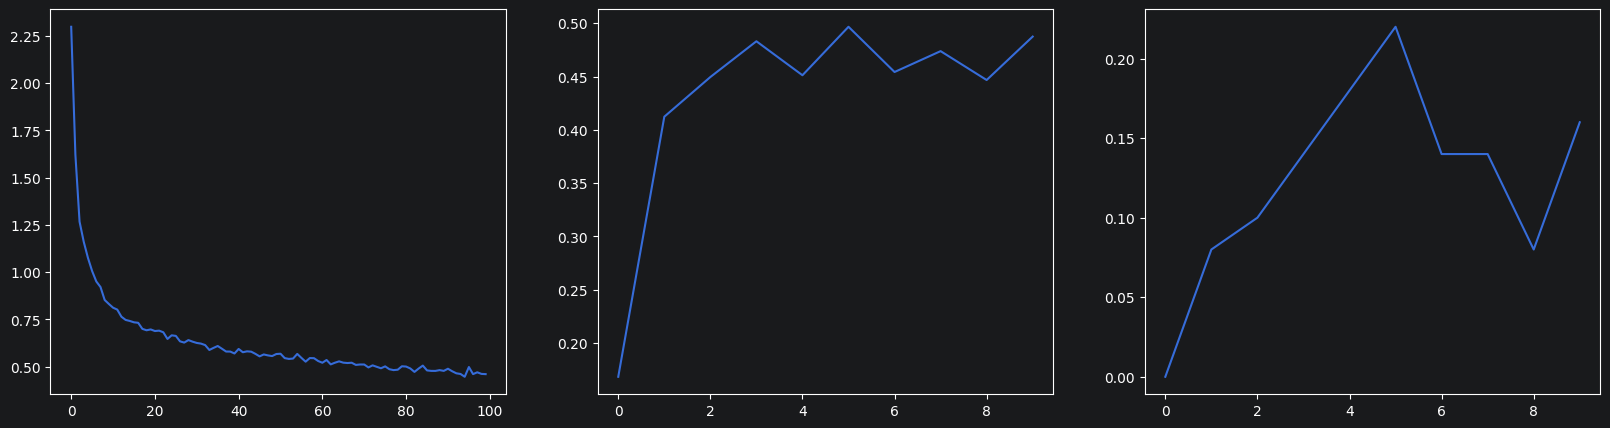

In [46]:
model = Model(vocab_size=len(wi), n_dim=128, n_head=8, layers=2, max_len=40)
lh, tl = lm_train(model, data, test, epochs=100, lr=0.001, batch_size=64, max_len=20)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

print(lh[-1])
ax[0].plot(lh)
l1, l2 = zip(*tl)
ax[1].plot(l1)
ax[2].plot(l2)
plt.show()

In [47]:

class TL(nn.Module):
    def __init__(self, n_dim, n_head):
        super(TL, self).__init__()
        self.mha = RMHA(n_dim, n_head)
        self.ff = nn.Sequential(
            nn.Linear(n_dim, n_dim * 4),
            nn.ReLU(),
            nn.Linear(n_dim * 4, n_dim),
        )

    def forward(self, x, m=None, freq=None, at=False):
        e = self.mha(x, m, freq)
        e = self.ff(e)
        return e


class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, layers=2, max_len=20):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)

        self.tl = nn.ModuleList([TL(n_dim, n_head) for _ in range(layers)])

        self.lm = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim

        pa = torch.arange(0, max_len)
        freq_size = torch.arange(0, n_dim // n_head // 2)
        base_frecs = 1.0 / torch.pow(20, 2 * freq_size / n_dim)

        self.fx = torch.flatten(pa.unsqueeze(-1) * base_frecs, end_dim=1).unsqueeze(0)

    def forward(self, x, m=None):
        e = self.emb(x)
        for tl in self.tl:
            e = tl(e, m, self.fx)
        return self.lm(e)

    def gen(self, s, max_len=10, bs=16):
        self.eval()

        ml = max([len(q) for q in s])
        at = [[1] * len(q) for q in s]
        s = ['-' * (ml - len(q)) + q for q in s]
        s = [[wi[q] for q in w] for w in s]
        at = [[0] * (ml - len(q)) + q for q in at]

        st = torch.LongTensor(s)
        at = torch.Tensor(at)

        res = []

        for x, m in DataLoader(TensorDataset(st, at), batch_size=bs, shuffle=False):
            for _ in range(max_len):
                with torch.no_grad():
                    o = self(x, m)
                    ne = o.exp().argmax(dim=-1)[:, -1].unsqueeze(1)
                    x = torch.cat([x, ne], dim=1)
                    m = torch.cat([m, torch.ones(m.shape[0], 1)], dim=1)
            res.append(x)

        fr = torch.cat(res, dim=0)
        fres = []
        for q in fr:
            fres.append(''.join([iw[c] for c in q.tolist()]))

        return fres

  0%|          | 0/200000 [00:00<?, ?it/s]

2.2774596586823463


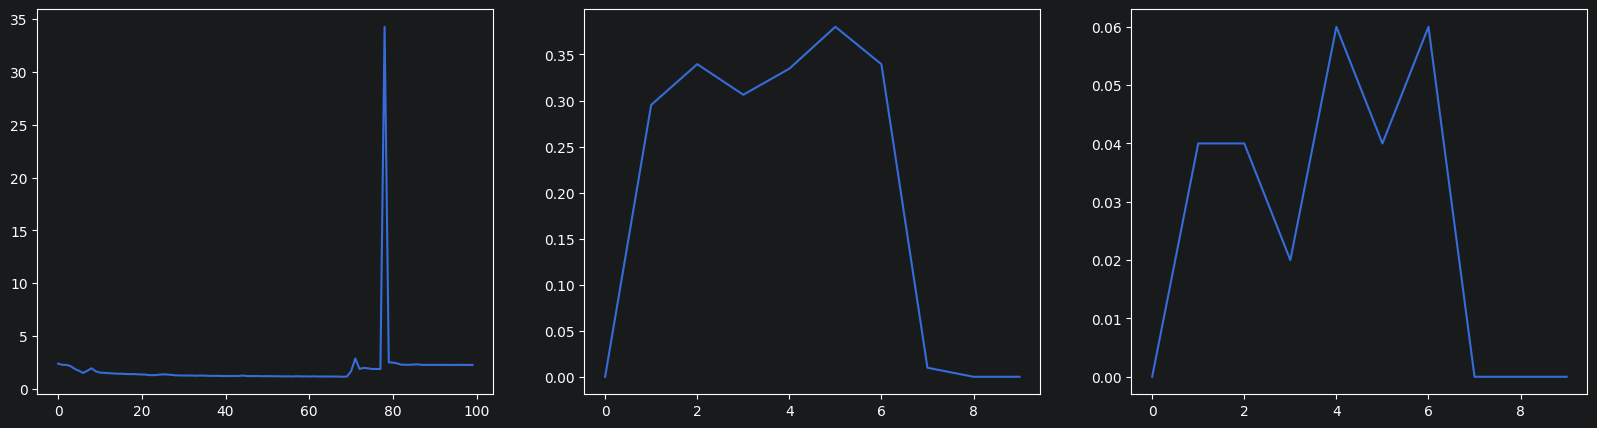

In [48]:
model = Model(vocab_size=len(wi), n_dim=128, n_head=8, layers=4, max_len=40)
lh, tl = lm_train(model, data, test, epochs=100, lr=0.001, batch_size=64, max_len=20)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

print(lh[-1])
ax[0].plot(lh)
l1, l2 = zip(*tl)
ax[1].plot(l1)
ax[2].plot(l2)
plt.show()

In [49]:

class TL(nn.Module):
    def __init__(self, n_dim, n_head):
        super(TL, self).__init__()
        self.mha = RMHA(n_dim, n_head)
        self.ff = nn.Sequential(
            nn.Linear(n_dim, n_dim * 4),
            nn.ReLU(),
            nn.Linear(n_dim * 4, n_dim),
        )

    def forward(self, x, m=None, freq=None, at=False):
        e = self.mha(x, m, freq) + x
        e = self.ff(e) + e
        return e


class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, layers=2, max_len=20):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)

        self.tl = nn.ModuleList([TL(n_dim, n_head) for _ in range(layers)])

        self.lm = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim

        pa = torch.arange(0, max_len)
        freq_size = torch.arange(0, n_dim // n_head // 2)
        base_frecs = 1.0 / torch.pow(20, 2 * freq_size / n_dim)

        self.fx = torch.flatten(pa.unsqueeze(-1) * base_frecs, end_dim=1).unsqueeze(0)

    def forward(self, x, m=None):
        e = self.emb(x)
        for tl in self.tl:
            e = tl(e, m, self.fx)
        return self.lm(e)

    def gen(self, s, max_len=10, bs=16):
        self.eval()

        ml = max([len(q) for q in s])
        at = [[1] * len(q) for q in s]
        s = ['-' * (ml - len(q)) + q for q in s]
        s = [[wi[q] for q in w] for w in s]
        at = [[0] * (ml - len(q)) + q for q in at]

        st = torch.LongTensor(s)
        at = torch.Tensor(at)

        res = []

        for x, m in DataLoader(TensorDataset(st, at), batch_size=bs, shuffle=False):
            for _ in range(max_len):
                with torch.no_grad():
                    o = self(x, m)
                    ne = o.exp().argmax(dim=-1)[:, -1].unsqueeze(1)
                    x = torch.cat([x, ne], dim=1)
                    m = torch.cat([m, torch.ones(m.shape[0], 1)], dim=1)
            res.append(x)

        fr = torch.cat(res, dim=0)
        fres = []
        for q in fr:
            fres.append(''.join([iw[c] for c in q.tolist()]))

        return fres

  0%|          | 0/200000 [00:00<?, ?it/s]

0.04164586037222762


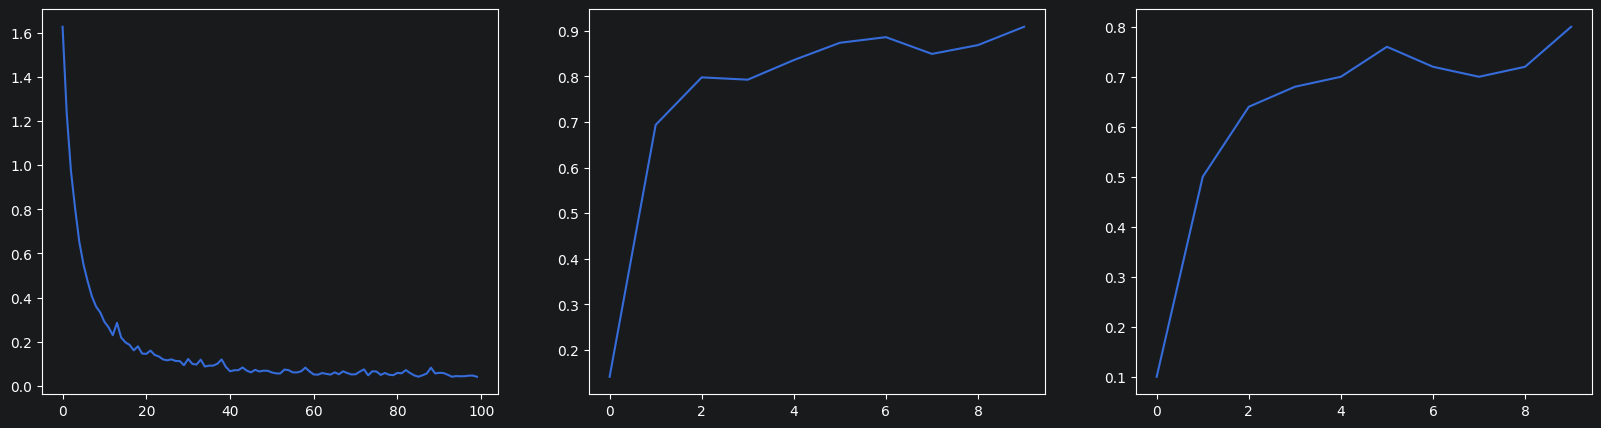

In [50]:
model = Model(vocab_size=len(wi), n_dim=128, n_head=8, layers=4, max_len=40)
lh, tl = lm_train(model, data, test, epochs=100, lr=0.001, batch_size=64, max_len=20)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

print(lh[-1])
ax[0].plot(lh)
l1, l2 = zip(*tl)
ax[1].plot(l1)
ax[2].plot(l2)
plt.show()

In [59]:
import requests

urls = [
    'https://en.wikipedia.org/wiki/Computer',
    'https://en.wikipedia.org/wiki/Operating_system',
    'https://en.wikipedia.org/wiki/Computer_hardware',
    'https://en.wikipedia.org/wiki/Software',
    'https://en.wikipedia.org/wiki/Central_processing_unit',
    'https://en.wikipedia.org/wiki/Computer_memory',
    'https://en.wikipedia.org/wiki/Turing_machine',
    'https://en.wikipedia.org/wiki/Trigonometric_functions'
]

texts = []
for url in urls:
    response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
    texts.append(response.text)


In [60]:
from bs4 import BeautifulSoup
import re


ft = []

for t in texts:
    doc = BeautifulSoup(t, 'html.parser')
    text = '\n'.join([x.text for x in doc.find('div', {'id': 'bodyContent'})])
    ft.append(text)

cleaned_text = re.sub(r'\n+', '\n', '\n\n'.join(ft))

In [61]:
from collections import Counter

In [62]:
def pair_counts(tks):
    c = Counter()

    for i in range(len(tks) - 1):
        c[(tks[i], tks[i + 1])] += 1

    return c


In [63]:
def merge_pair(tks, pair, n_id):
    new_tks = []
    i = 0
    while i < len(tks):
        if i < len(tks) - 1 and (tks[i], tks[i + 1]) == pair:
            new_tks.append(n_id)
            i += 2
        else:
            new_tks.append(tks[i])
            i += 1

    return new_tks


In [64]:
from tqdm.auto import tqdm

def bpe(t, vs):

    tks = list(t.encode('utf-8'))
    merges = {}
    vocab = {i: bytes([i]) for i in range(256)}

    for _ in tqdm(range(vs - len(vocab))):
        pc = pair_counts(tks)

        mc = pc.most_common(1)[0][0]
        nid = len(vocab) + 1
        tks = merge_pair(tks, mc, nid)
        vocab[nid] = vocab[mc[0]] + vocab[mc[1]]
        merges[mc] = nid

    return vocab, merges

v, m = bpe(cleaned_text, 1000)

  0%|          | 0/744 [00:00<?, ?it/s]

In [65]:
def encode(t, merges):
    tks = list(t.encode('utf-8'))

    while len(tks) >= 2:
        mc = pair_counts(tks).most_common(1)[0][0]
        if mc not in merges:
            break
        tks = merge_pair(tks, mc, merges[mc])

    return tks

et = encode(cleaned_text, m)
print(len(et))

196368


In [66]:
def decode(tks, vocab):
    return b''.join([vocab[t] for t in tks]).decode('utf-8')

dt = decode(et, v)
print(dt[:1000] == cleaned_text[:1000])
print(dt[:1000])


True

From Wikipedia, the free encyclopedia
Programmable machine that processes data
For the consumer-oriented device which is also called a computer, see Personal computer.
For other uses, see Computer (disambiguation).
Computers and computing devices from different eras—left to right, top to bottom:
Early vacuum-tube computer (ENIAC)Mainframe computer (IBM System/360)Smartphone (LYF Water 2)Desktop computer (IBM ThinkCentre S50 with monitor)Supercomputer (IBM Summit)
A computer is a machine that can be programmed to automatically carry out sequences of arithmetic or logical operations (computation). Modern digital electronic computers can perform generic sets of operations known as programs, which enable computers to perform a wide range of tasks. The term computer system may refer to a nominally complete computer that includes the hardware, operating system, software, and peripheral equipment needed and used for full operation, or to a group of computers that are linked and function

In [67]:
import re

GPT2_PATTERN = r"""'s|'t|'re|'ve|'m|'ll|'d| ?\w+| ?\d+| ?[^\s\w\d]+|\s+"""

text = "Hello world! It's a test_123."
chunks = re.findall(GPT2_PATTERN, text)
print(chunks)

['Hello', ' world', '!', ' It', "'s", ' a', ' test_123', '.']


In [68]:
def pbpe(t, vs):

    tks = [list(q.encode('utf-8')) for q in re.findall(GPT2_PATTERN, t)]
    merges = {}
    vocab = {i: bytes([i]) for i in range(256)}

    for _ in tqdm(range(vs - len(vocab))):
        fc = Counter()
        for q in tks:
            fc.update(pair_counts(q))
        if len(fc) == 0:
            break
        mc = fc.most_common(1)[0][0]
        nid = len(vocab)
        tks = [q if len(q) <= 1 else merge_pair(q, mc, nid) for q in tks]
        vocab[nid] = vocab[mc[0]] + vocab[mc[1]]
        merges[mc] = nid

    return vocab, merges


v, m = pbpe(cleaned_text, 5000)

  0%|          | 0/4744 [00:00<?, ?it/s]

In [69]:
def pencode(t, merges):
    tks = re.findall(GPT2_PATTERN, t)
    at = []
    for q in tks:
        q = list(q.encode('utf-8'))
        while len(q) >= 2:
            fc = pair_counts(q)
            mc = fc.most_common()
            bc = None

            for c, _ in mc:
                if c in merges:
                    if bc is None or merges[c] < merges[bc]:
                        bc = c

            if bc is None:
                break
            q = merge_pair(q, bc, merges[bc])
        at.extend(q)

    return at



In [70]:
# v, m = pbpe(cleaned_text, 1000)
et = pencode(cleaned_text, m)
print(len(et))
dt = decode(et, v)
print(dt[:1000] == cleaned_text[:1000])
print(dt[:1000])

138689
True

From Wikipedia, the free encyclopedia
Programmable machine that processes data
For the consumer-oriented device which is also called a computer, see Personal computer.
For other uses, see Computer (disambiguation).
Computers and computing devices from different eras—left to right, top to bottom:
Early vacuum-tube computer (ENIAC)Mainframe computer (IBM System/360)Smartphone (LYF Water 2)Desktop computer (IBM ThinkCentre S50 with monitor)Supercomputer (IBM Summit)
A computer is a machine that can be programmed to automatically carry out sequences of arithmetic or logical operations (computation). Modern digital electronic computers can perform generic sets of operations known as programs, which enable computers to perform a wide range of tasks. The term computer system may refer to a nominally complete computer that includes the hardware, operating system, software, and peripheral equipment needed and used for full operation, or to a group of computers that are linked and f

In [91]:
s = 64
r = []
m = []
lm = []
for i in range(0, len(et) - s, 32):
    r.append(et[i:i + s])
    m.append([1] * s)
    lm.append([1] * s)

wdata = TensorDataset(torch.LongTensor(r), torch.Tensor(m), torch.Tensor(lm))

In [92]:

class TL(nn.Module):
    def __init__(self, n_dim, n_head):
        super(TL, self).__init__()
        self.mha = RMHA(n_dim, n_head)
        self.ff = nn.Sequential(
            nn.Linear(n_dim, n_dim * 4),
            nn.ReLU(),
            nn.Linear(n_dim * 4, n_dim),
            nn.Dropout(0.1)
        )

    def forward(self, x, m=None, freq=None, at=False):
        e = self.mha(x, m, freq) + x
        e = self.ff(e) + e
        return e


class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, layers=2, max_len=20):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)

        self.tl = nn.ModuleList([TL(n_dim, n_head) for _ in range(layers)])

        self.lm = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim

        pa = torch.arange(0, max_len)
        freq_size = torch.arange(0, n_dim // n_head // 2)
        base_frecs = 1.0 / torch.pow(32, 2 * freq_size / n_dim)

        self.fx = torch.flatten(pa.unsqueeze(-1) * base_frecs, end_dim=1).unsqueeze(0)

    def forward(self, x, m=None):
        e = self.emb(x)
        for tl in self.tl:
            e = tl(e, m, self.fx)
        return self.lm(e)

    def gen(self, s, max_len=10, bs=16):
        self.eval()

        ml = max([len(q) for q in s])
        at = [[1] * len(q) for q in s]
        s = ['-' * (ml - len(q)) + q for q in s]
        s = [[wi[q] for q in w] for w in s]
        at = [[0] * (ml - len(q)) + q for q in at]

        st = torch.LongTensor(s)
        at = torch.Tensor(at)

        res = []

        for x, m in DataLoader(TensorDataset(st, at), batch_size=bs, shuffle=False):
            for _ in range(max_len):
                with torch.no_grad():
                    o = self(x, m)
                    ne = o.exp().argmax(dim=-1)[:, -1].unsqueeze(1)
                    x = torch.cat([x, ne], dim=1)
                    m = torch.cat([m, torch.ones(m.shape[0], 1)], dim=1)
            res.append(x)

        fr = torch.cat(res, dim=0)
        fres = []
        for q in fr:
            fres.append(''.join([iw[c] for c in q.tolist()]))

        return fres

  0%|          | 0/216650 [00:00<?, ?it/s]

0.6995518696923977


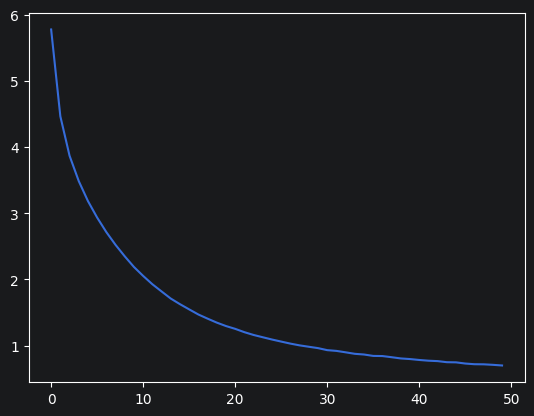

In [93]:
model = Model(vocab_size=len(v), n_dim=128, n_head=8, layers=4, max_len=80)
lh, tl = lm_train(model, wdata, None, epochs=50, lr=0.001, batch_size=16, max_len=80)

print(lh[-1])
plt.plot(lh)
plt.show()

In [99]:
def gen(self, s, v, m, max_len=10, bs=16):
    self.eval()
    se = [pencode(q, m) for q in s]
    ml = max([len(q) for q in s])
    at = [[1] * len(q) for q in s]
    se = [[35] * (ml - len(q)) + q for q in se]
    at = [[0] * (ml - len(q)) + q for q in at]

    st = torch.LongTensor(se)
    at = torch.Tensor(at)

    res = []

    for x, m in DataLoader(TensorDataset(st, at), batch_size=bs, shuffle=False):
        for _ in range(max_len):
            with torch.no_grad():
                o = self(x, m)
                ne = torch.multinomial(o.exp()[:, -1], num_samples=1)
                x = torch.cat([x, ne], dim=1)
                m = torch.cat([m, torch.ones(m.shape[0], 1)], dim=1)
        res.append(x)

    fr = torch.cat(res, dim=0)
    fres = []
    for q in fr:
        fres.append(''.join(decode(q.tolist(), v)))

    return fres

s = ['A computer is']

print(gen(model, s, v, m, max_len=100, bs=16)[0])

A computer iselusual occup note amps perpitérale.
In most often in the analysis of Turing model the sal 16
While studied by the approximation of Turing makes them and disting by Gödel's proofs:[cals with functionaluous challenge Ral acquination for conditional camation of real functions in 1. The numbered reprogrammable gate (4). The abbreviations in computing) to calculating machines shrength sole
